In [2]:
import pandas as pd
import numpy as np

import altair as alt

In [3]:
df = pd.read_csv('fec/totals-2020-01-20T18_57_22.csv')
df['cash'] = df['cash_on_hand_end_period'].apply(lambda x: '${:,d}'.format(int(x)))

In [4]:
# df.info()

In [5]:
df = df.sort_values('cash_on_hand_end_period')

In [6]:
df_contribs_1 = pd.read_csv('fec/contribs_pfluger-berryhill.csv')
df_contribs_2 = pd.read_csv('fec/contribs_cady-schumann.csv')

In [7]:
df_conaway = pd.read_csv('fec/conaway.csv')

In [8]:
frames = [df_contribs_1, df_contribs_2, df_conaway]

In [9]:
df_contribs = pd.concat(frames)

In [10]:
# df_contribs.info()

In [11]:
contribs_grouped = df_contribs.groupby('committee_name').contribution_receipt_amount.sum()

In [12]:
# contribs_grouped.to_csv('fec/contribs_sum.csv', headers=True)

In [13]:
contribs = pd.read_csv('fec/contribs_sum.csv')

In [14]:
merged = pd.merge(df, contribs, on='name')

In [15]:
# merged.head()

In [16]:
totals_2019 = pd.read_csv('fec/totals_2019.csv')
totals_2019 = totals_2019.sort_values('cash_on_hand_end_period').reset_index(drop=True)
# totals_2019 = totals_2019.drop([11])
totals_2019

,name,receipts,disbursements,cash_on_hand_end_period,debts_owed_by_committee
0,Ross Alan Schumann,0.00,0.00,0.00,0.00
1,Brandon Batch,0.00,0.00,0.00,0.00
2,Wesley Virdell,0.00,0.00,0.00,0.00
3,Richard Bartlett,22620.81,22620.81,0.00,0.00
4,Wacey Alpha Cody,0.00,0.00,0.00,0.00
5,Jeffrey Cady,0.00,0.00,0.00,0.00
6,James Berryhill,0.00,0.00,0.00,0.00
7,Ned Luscombe,0.00,0.00,0.00,0.00
8,Casey Gray,0.00,0.00,0.00,0.00
9,James Faircloth,0.00,0.00,0.00,0.00


In [17]:
totals_2019 = totals_2019.reset_index(drop=False)
totals_2019

,index,name,receipts,disbursements,cash_on_hand_end_period,debts_owed_by_committee
0,0,Ross Alan Schumann,0.00,0.00,0.00,0.00
1,1,Brandon Batch,0.00,0.00,0.00,0.00
2,2,Wesley Virdell,0.00,0.00,0.00,0.00
3,3,Richard Bartlett,22620.81,22620.81,0.00,0.00
4,4,Wacey Alpha Cody,0.00,0.00,0.00,0.00
5,5,Jeffrey Cady,0.00,0.00,0.00,0.00
6,6,James Berryhill,0.00,0.00,0.00,0.00
7,7,Ned Luscombe,0.00,0.00,0.00,0.00
8,8,Casey Gray,0.00,0.00,0.00,0.00
9,9,James Faircloth,0.00,0.00,0.00,0.00


In [18]:
# totals_2019.level_0 = totals_2019.index * 20
# totals_2019

In [41]:
all_totals = pd.merge(totals_2019, contribs, on='name')
all_totals.rename(columns={'debts_owed_by_committee':'Debts', 'contributions':'Contributions'})
# all_totals.to_csv('fec/all_totals_2019.csv', header=True)
# all_totals.to_json('fec/all_totals_2019.json', orient='index')

,index,name,receipts,disbursements,cash_on_hand_end_period,Debts,Contributions
0,0,Ross Alan Schumann,0.00,0.00,0.00,0.00,0.00
1,1,Brandon Batch,0.00,0.00,0.00,0.00,0.00
2,2,Wesley Virdell,0.00,0.00,0.00,0.00,0.00
3,3,Richard Bartlett,22620.81,22620.81,0.00,0.00,22350.00
4,4,Wacey Alpha Cody,0.00,0.00,0.00,0.00,0.00
5,5,Jeffrey Cady,0.00,0.00,0.00,0.00,0.00
6,6,James Berryhill,0.00,0.00,0.00,0.00,0.00
7,7,Ned Luscombe,0.00,0.00,0.00,0.00,0.00
8,8,Casey Gray,0.00,0.00,0.00,0.00,0.00
9,9,James Faircloth,0.00,0.00,0.00,0.00,0.00


In [21]:
# chart.save('vegachart.html')

In [22]:
json = pd.read_json('fec/all_totals_2019.json')

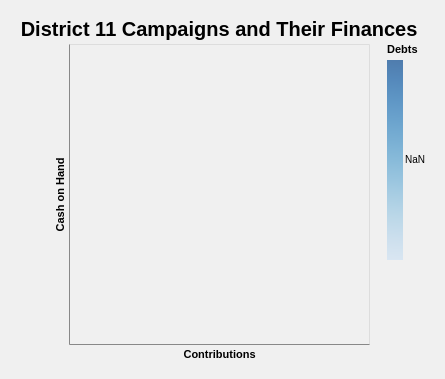

In [43]:
selection = alt.selection_single(on='mouseover', fields=['name','cash_on_hand_end_period', 'contributions'])

# color = alt.condition(selection,
#                      alt.Color('name:N', legend=None),
#                       alt.value('lightgray')
#                      )

def mult_index(number):
    return number * 10

bubble = alt.Chart(
    all_totals, width=300,
    height=300,
    title='District 11 Campaigns and Their Finances',
    padding=20).mark_circle(strokeWidth=1,
    strokeOpacity=1,
    stroke='#666666').encode(
        alt.X('Contributions:Q', scale=alt.Scale(zero=False, type='sqrt'), title='Contributions'),
        alt.Y('cash_on_hand_end_period:Q', scale=alt.Scale(zero=False, type='sqrt'), sort='ascending', title='Cash on Hand'),
        alt.Size('Contributions:Q', scale=alt.Scale(range=[100, 10000]), legend=None),
        tooltip=[
            alt.Tooltip(title='Name', field='name', type='ordinal'),
            alt.Tooltip(title='Contributions', field='Contributions', format="$,.0f", type='ordinal'),
            alt.Tooltip(title='Cash on Hand', field='cash_on_hand_end_period', format="$,.0f", type='ordinal'),
            alt.Tooltip(title='Disbursements', field='disbursements', format="$,.0f", type='ordinal'),
            alt.Tooltip(title='Debts', field='Debts', format="$,.0f", type='ordinal')
        ],
        color = alt.Color('Debts:Q'),
    #     strokeWidth='1:O'
    ).add_selection(
        selection
    ).configure_axis(
        gridOpacity=0.3,
        gridColor='cornflowerblue',
        domain=False
    ).configure_view(
        strokeWidth=1,
        stroke='cornflowerblue',
        strokeOpacity=0.3
    ).configure_scale(
        minSize=100,
        continuousPadding=4,
        maxOpacity=0.9,
        minOpacity=0.4,
        pointPadding=0.3,
    ).configure_legend(
        offset=50
    ).configure(
        background='#f0f0f0'
    ).configure_title(
        fontSize=20
    )

bubble

In [44]:
bubble.save('vegabubble.html')